## **Carregar bibliotecas**

In [1]:
# Load the used classes
from modules_otft._imports import *
from modules_otft._read_data import ReadData
from modules_otft._model import TFTModel
from modules_otft._grafics import  TFTGraphicsPlot
from modules_otft._menu import TFTMenu

# from modules_otft._global_vars import *
from modules_otft._config import *
from modules_otft._utils import *
from modules_otft._display import display_settings

## **Gerar dados sintéticos**   

In [2]:
from modules_otft._generate_synthetic_data import SyntheticFromSettings

plot = TFTGraphicsPlot()
menu = TFTMenu()
read = ReadData()



In [4]:
# Read and show the path file Json
settings = enter_with_json_file()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


___________________________________________________________________________________ SETTINGS PRESENT IN THE JSON FILE:___________________________________________________________________________________

| path: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/datas/Cnts/tipo p
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| experimental_data_scale_transfer: A
---------------------------------------------------------------------------

In [5]:
ld_voltages = get_load_voltages(settings)

type_curve_plot = get_type_plot(settings)

shift_list = calculate_shift_list(settings)

list_tension_shift = get_shift_list(read, settings)

path_voltages = read.read_files_experimental(settings['path'], list_tension_shift)

Vv, Id, input_voltage, n_points, count_transfer, count_output = read.load_data(settings['type_read_data_exp'], path_voltages, settings['current_typic'], settings['experimental_data_scale_transfer'], settings['experimental_data_scale_output'], type_curve_plot)


In [3]:
# Caso o Shift seja aplicado 
path_voltages, new_values_tension, new_list_tension = filter_and_load_files(read, settings, path_voltages, list_tension_shift)

Vv, Id, input_voltage, n_points, count_transfer, count_output = read.load_data(settings['type_read_data_exp'], path_voltages, settings['current_typic'], settings['experimental_data_scale_transfer'], settings['experimental_data_scale_output'], type_curve_plot)
list_tension_shift = new_values_tension
list_tension = new_list_tension


NameError: name 'settings' is not defined

In [7]:
Model = TFTModel(list_tension, n_points)


In [7]:
gen = SyntheticFromSettings(settings, model_cls=TFTModel, out_root="synthetic_from_settings")

In [9]:
# gerar 8 variações sintéticas por cada arquivo experimental encontrado
generated_index = gen.generate(resample_n_points=10000, variation_mode="voltages", voltage_increment=2.0, voltage_max_variation=10)


Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg32V_synth_000.csv | Tensão: -32.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg34V_synth_001.csv | Tensão: -34.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg36V_synth_002.csv | Tensão: -36.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg38V_synth_003.csv | Tensão: -38.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg40V_synth_004.csv | Tensão: -40.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg42V_synth_000.csv | Tensão: -42.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg44V_synth_001.csv | Tensão: -44.0 V | params(Vtho=8.57, Jth=0.097)
Gerado: synthetic_from_settings/Org1/tipo_p/output/output-neg46V_synth_002.csv | Tensão: -46.0 V | param

## **Treinar modelo MLP**

In [3]:
from modules_otft._mlp_train import MLPModelTrain 

In [4]:

BASE_PATH = "/home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/"
INDEX_PATH = BASE_PATH + "models/Mlp_Org1/exp6/index_generated_exp6.json"
TECNOLOGY = "org1"

In [6]:
# Definição dos parâmetros do treino
HIDDEN_LAYERS = (3, 3, 3)
EPOCS = 10000  # Máximo de épocas
TEST_SPLIT = 0.2      # 20% para teste/validação
LEARNING_RATE = 0.0002931453661651854
BATSIZE = 64
PATIENCE = 1000




# Instanciação do Otimizador/Treinador
mlp_trainer = MLPModelTrain(
    index_path=INDEX_PATH,
    hidden_layers=HIDDEN_LAYERS,
    activation='tanh',
    learning_rate=LEARNING_RATE,
    max_iter=EPOCS,
    batch_size=BATSIZE,
    n_iter=PATIENCE,
    test_size=TEST_SPLIT,
    model_path=f'models/mlp_model_{TECNOLOGY}.pkl',
    
)

print(f"Estrutura da MLP definida: Input (5 features) -> {HIDDEN_LAYERS[0]} -> {HIDDEN_LAYERS[1]} -> {HIDDEN_LAYERS[2]} -> Output (ln|Id|)")

Estrutura da MLP definida: Input (5 features) -> 3 -> 3 -> 3 -> Output (ln|Id|)


In [6]:
# Inicia o processo de treinamento
# Este método retorna o modelo treinado e o scaler_X ajustado
mlp_trainer.train_model()

Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp6/index_generated_exp6.json
Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (3, 3, 3) -> Output(1)
Total de Parâmetros Treináveis: 46
Epoch 1/10000 - loss: 0.4092 - val_loss: 0.4162 - acc: 0.5899 - val_acc: 0.5874
Epoch 2/10000 - loss: 0.2004 - val_loss: 0.2055 - acc: 0.7991 - val_acc: 0.7963
Epoch 3/10000 - loss: 0.1078 - val_loss: 0.1103 - acc: 0.8920 - val_acc: 0.8907
Epoch 4/10000 - loss: 0.0530 - val_loss: 0.0541 - acc: 0.9468 - val_acc: 0.9463
Epoch 5/10000 - loss: 0.0295 - val_loss: 0.0300 - acc: 0.9704 - val_acc: 0.9703
Epoch 6/10000 - loss: 0.0214 - val_loss: 0.0216 - acc: 0.9785 - val_acc: 0.9786
Epoch 7/10000 - loss: 0.0178 - val_loss: 0.0179 - acc: 0.9822 - val_acc: 0.9823
Epoch 8/10000 - loss: 0.0153 - val_loss: 0.0154 - acc: 0.9847 - val_acc: 0.9848
Epoch 9/10000 - loss: 0.0131 - val_loss: 0.01

8.436217467533424e-05

In [ ]:
path_model_optimized = "/home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp1/mlp_model_v1.keras"
# models/Mlp_Org3/optuna_best/mlp_model_org3_trial_22.pkl

In [24]:
# Carregar o modelo treinado para inferência
trained_model, feature_scaler, target_scaler = mlp_trainer.load_model(filename=path_model_optimized)

In [25]:
# Importações necessárias 
from modules_otft._inferency import plot_curve_comparison, prepare_mlp_features, load_data_for_inference
import numpy as np


In [28]:
# Arquivo CSV de teste e seus metadados
TEST_CSV_PATH = '/home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/infer_curve.json'
V_real, I_real, v_fixed, is_transfer = load_data_for_inference(TEST_CSV_PATH)



In [19]:

plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,  
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    
    # Passando os objetos treinados: (Função de preparo, Modelo, Scaler)
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler), 
    
    yscale="log",  # Escala linear para corrente
    title=f"Previsão MLP vs. Curva Real ({os.path.basename(TEST_CSV_PATH)})"
)

In [22]:

plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,  
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    
    # Passando os objetos treinados: (Função de preparo, Modelo, Scaler)
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler), 
    
    yscale="linear",  # Escala linear para corrente
    title=f"Previsão MLP vs. Curva Real ({os.path.basename(TEST_CSV_PATH)})"
)

In [ ]:

plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,  
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    
    # Passando os objetos treinados: (Função de preparo, Modelo, Scaler)
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler), 
    
    yscale="linear",  # Escala linear para corrente
    title=f"Previsão MLP vs. Curva Real ({os.path.basename(TEST_CSV_PATH)})"
)

In [30]:

plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,  
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    
    # Passando os objetos treinados: (Função de preparo, Modelo, Scaler)
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler), 
    
    yscale="linear",  # Escala linear para corrente
    title=f"Previsão MLP vs. Curva Real ({os.path.basename(TEST_CSV_PATH)})"
)

In [19]:
# Carregar o modelo treinado para inferência
trained_model, feature_scaler, target_scaler = mlp_trainer.load_model(filename="models/Mlp_Org1/optuna_best/mlp_model_org1_trial_29.pkl")

In [23]:
# Arquivo CSV de teste e seus metadados
TEST_CSV_PATH = 'models/Mlp_Org1/infer_curve.json'
V_real, I_real, v_fixed, is_transfer = load_data_for_inference(TEST_CSV_PATH)



In [26]:

plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,  
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    
    # Passando os objetos treinados: (Função de preparo, Modelo, Scaler)
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler), 
    
    yscale="log",  # Escala linear para corrente
    title=f"Previsão MLP vs. Curva Real ({os.path.basename(TEST_CSV_PATH)})"
)

## **Determinar Hiperparametros de forma autmática (OPTUNA)**

In [16]:
import optuna
import warnings

# Suprime os avisos do Scikit-Learn para o terminal
warnings.filterwarnings('ignore') 

INDEX_PATH = BASE_PATH + "models/Mlp_Org1/exp6/index_generated_exp6.json"
TECNOLOGY = "org1"


In [17]:
def objective(trial):
    """
    Função objetivo otimizada para encontrar a rede mais simples (minimalista).
    """
    
    # --- 1. DEFINIÇÃO DO ESPAÇO DE BUSCA MINIMALISTA ---
    
    # Como 3 camadas funcionaram, testamos de 1 a 3 para ver se algo mais simples resolve.
    n_layers = trial.suggest_int('n_layers', 1, 3)
    
    hidden_layers = []
    for i in range(n_layers):
        # Reduzimos o range: de 1 a 5 neurônios apenas. 
        # O step=1 permite testar 1, 2, 3, 4 ou 5 neurônios individualmente.
        n_units = trial.suggest_int(f'n_units_layer_{i}', 1, 5)
        hidden_layers.append(n_units)
    
    hidden_layers = tuple(hidden_layers)
    
    # Manteremos as funções de ativação, mas 'tanh' costuma performar bem em redes muito pequenas
    activation = trial.suggest_categorical('activation', ['relu', 'tanh', 'silu'])
    
    # Ajuste fino da taxa de aprendizado e batch size para redes pequenas
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64]) # Batches menores ajudam no fit de redes pequenas
    
    # --- 2. INSTANCIAÇÃO DO MODELO ---
    
    print(f"\n--- Iniciando Trial {trial.number} ---")
    print(f"Testando Simplicidade: {hidden_layers} | {activation} | LR: {learning_rate:.5f}")
    
    temp_model_path = f'models/optuna_trials/mlp_model_{TECNOLOGY}_trial_{trial.number}.pkl'
    
    mlp_trainer = MLPModelTrain(
        index_path=INDEX_PATH,
        hidden_layers=hidden_layers,
        activation=activation,
        learning_rate=learning_rate,
        max_iter=5000,    # Aumentei um pouco pois redes muito pequenas podem demorar mais para convergir
        batch_size=batch_size,
        n_iter=150,       # Aumentei a paciência para garantir que ela aprenda com poucos neurônios
        test_size=0.2,
        model_path=temp_model_path
    )
    
    # --- 3. TREINAMENTO E RETORNO ---
    
    try:
        val_mse = mlp_trainer.train_model()
        
        # Opcional: Penalização por complexidade (Sugerido abaixo)
        return val_mse + (0.0001 * sum(hidden_layers)) 
        
        # return val_mse
        
    except Exception as e:
        print(f"Erro no trial {trial.number}: {e}")
        raise optuna.exceptions.TrialPruned()

In [18]:

# --- EXECUÇÃO ---

# Criamos o estudo dizendo ao Optuna para MINIMIZAR o valor retornado (val_mse)
study = optuna.create_study(direction="minimize", study_name="Otimizacao_MLP_OTFT")

print("Iniciando a otimização de Hiperparâmetros com Optuna...")
# Executa 30 tentativas. 
study.optimize(objective, n_trials=30)

# --- RESULTADOS FINAIS ---
print("\n" + "="*60)
print("🎯 BUSCA DO OPTUNA CONCLUÍDA!")
print(f"🏆 Melhor MSE de Validação: {study.best_value:.6e}")
print("🧠 Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")
print("="*60)

[I 2026-03-14 07:21:59,886] A new study created in memory with name: Otimizacao_MLP_OTFT


Iniciando a otimização de Hiperparâmetros com Optuna...

--- Iniciando Trial 0 ---
Testando Simplicidade: (5, 1, 3) | silu | LR: 0.00021
Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp6/index_generated_exp6.json


[I 2026-03-14 07:22:00,148] Trial 0 pruned. 


Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (5, 1, 3) -> Output(1)
Total de Parâmetros Treináveis: 46
Erro no trial 0: The 'activation' parameter of MLPRegressor must be a str among {'relu', 'identity', 'logistic', 'tanh'}. Got 'silu' instead.

--- Iniciando Trial 1 ---
Testando Simplicidade: (1, 5, 1) | tanh | LR: 0.00082
Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp6/index_generated_exp6.json
Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (1, 5, 1) -> Output(1)
Total de Parâmetros Treináveis: 24
Epoch 1/5000 - loss: 0.1589 - val_loss: 0.1598 - acc: 0.8408 - val_acc: 0.8416
Epoch 2/5000 - loss: 0.0577 - val_loss: 0.0568 - acc: 0.9422 - val_acc: 0.9437
Epoch 3/5000 - loss: 0.0320 - val_loss: 0.0310 - acc: 0.9679 - val_acc: 0.9693
Epoch 4/5000 - loss: 0.0237 - val_loss: 0

[I 2026-03-14 07:37:07,253] Trial 1 finished with value: 0.006093637344241142 and parameters: {'n_layers': 3, 'n_units_layer_0': 1, 'n_units_layer_1': 5, 'n_units_layer_2': 1, 'activation': 'tanh', 'learning_rate': 0.00081914954402877, 'batch_size': 32}. Best is trial 1 with value: 0.006093637344241142.


...


--- Iniciando Trial 27 ---
Testando Simplicidade: (4,) | relu | LR: 0.00132
Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp6/index_generated_exp6.json
Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (4,) -> Output(1)
Total de Parâmetros Treináveis: 29
Epoch 1/5000 - loss: 0.0338 - val_loss: 0.0337 - acc: 0.9662 - val_acc: 0.9665
Epoch 2/5000 - loss: 0.0215 - val_loss: 0.0221 - acc: 0.9785 - val_acc: 0.9781
Epoch 3/5000 - loss: 0.0196 - val_loss: 0.0205 - acc: 0.9804 - val_acc: 0.9796
Epoch 4/5000 - loss: 0.0164 - val_loss: 0.0172 - acc: 0.9836 - val_acc: 0.9829
Epoch 5/5000 - loss: 0.0153 - val_loss: 0.0163 - acc: 0.9846 - val_acc: 0.9838
Epoch 6/5000 - loss: 0.0145 - val_loss: 0.0155 - acc: 0.9855 - val_acc: 0.9847
Epoch 7/5000 - loss: 0.0140 - val_loss: 0.0148 - acc: 0.9860 - val_acc: 0.9853
Epoch 8/5000 - loss: 0.0134 - val_loss: 0.0143 - acc: 0.9866

[I 2026-03-14 13:30:02,540] Trial 27 finished with value: 0.0029083438958972694 and parameters: {'n_layers': 1, 'n_units_layer_0': 4, 'activation': 'relu', 'learning_rate': 0.0013217262062061896, 'batch_size': 16}. Best is trial 22 with value: 0.0011741798038594426.
[I 2026-03-14 13:30:02,745] Trial 28 pruned. 



--- Iniciando Trial 28 ---
Testando Simplicidade: (4, 4) | silu | LR: 0.00383
Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp6/index_generated_exp6.json
Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (4, 4) -> Output(1)
Total de Parâmetros Treináveis: 49
Erro no trial 28: The 'activation' parameter of MLPRegressor must be a str among {'relu', 'identity', 'logistic', 'tanh'}. Got 'silu' instead.

--- Iniciando Trial 29 ---
Testando Simplicidade: (5,) | tanh | LR: 0.00030
Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/Mlp_Org1/exp6/index_generated_exp6.json
Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (5,) -> Output(1)
Total de Parâmetros Treináveis: 36
Epoch 1/5000 - loss: 0.1385 - val_loss: 0.1402 - acc: 0.8612 - val_acc: 0.8610


[I 2026-03-14 13:55:50,569] Trial 29 finished with value: 0.0008592033754102886 and parameters: {'n_layers': 1, 'n_units_layer_0': 5, 'activation': 'tanh', 'learning_rate': 0.00029548794566701023, 'batch_size': 64}. Best is trial 29 with value: 0.0008592033754102886.



🎯 BUSCA DO OPTUNA CONCLUÍDA!
🏆 Melhor MSE de Validação: 8.592034e-04
🧠 Melhores Hiperparâmetros encontrados:
    n_layers: 1
    n_units_layer_0: 5
    activation: tanh
    learning_rate: 0.00029548794566701023
    batch_size: 64


In [20]:
# Carregar o modelo treinado com os melhores hiperparâmetros para inferência
best_trial_number = study.best_trial.number
best_model_path = f'models/optuna_trials/mlp_model_{TECNOLOGY}_trial_{best_trial_number}.pkl'
trained_model, feature_scaler, target_scaler = mlp_trainer.load_model(filename=best_model_path)

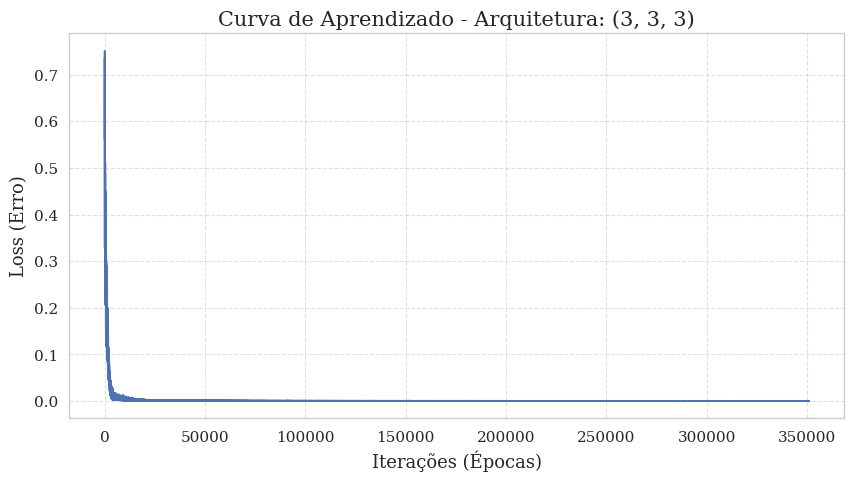

In [21]:
import matplotlib.pyplot as plt

def plot_learning_curve(mlp_trainer):
    """
    Plota a evolução do erro durante o treinamento.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(mlp_trainer.model.loss_curve_)
    plt.title(f'Curva de Aprendizado - Arquitetura: {mlp_trainer.hidden_layers}')
    plt.xlabel('Iterações (Épocas)')
    plt.ylabel('Loss (Erro)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Após o fit no seu script principal, basta chamar:
plot_learning_curve(mlp_trainer)